In [ ]:
'''
from google.colab import drive
drive.mount('/content/drive')
'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy.linalg as la

In [ ]:
google_folder_path = "/content/drive/MyDrive/Cornell Tech/ORIE 5530/202507-citibike-tripdata/"
vs_file_path = "/Users/samanthataylor/Library/CloudStorage/OneDrive-Personal/Documents/Cornell Tech/Fall 2025/ORIE 5530 - Modeling Under Uncertainty/midterm/202507-citibike-tripdata/"

# Load in the Data

In [ ]:
raw_df = pd.DataFrame()
for i in range (1, 6):
    file_name = "202507-citibike-tripdata_" + str(i) + ".csv"
    raw_df = pd.concat([raw_df, pd.read_csv(vs_file_path + file_name, dtype={7: str})], ignore_index=True)

In [ ]:
print("Total number of rows: " + str(len(raw_df.index)))
raw_df.head()

Total number of rows: 4988053


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,BF31E940F7D80958,electric_bike,2025-07-11 18:42:36.430,2025-07-11 18:46:37.195,N 6 St & Bedford Ave,5379.10,Broadway & Berry St,5164.05,40.717452,-73.958509,40.710361,-73.965304,member
1,0DF0EDCFF6452D83,electric_bike,2025-07-12 19:11:05.558,2025-07-12 19:20:05.429,Huron St & Franklin St,5869.04,Broadway & Berry St,5164.05,40.732660,-73.958260,40.710361,-73.965304,member
2,9AFD3BA9E53733E7,electric_bike,2025-07-02 19:38:18.759,2025-07-02 20:10:05.899,Macon St & Howard Ave,4408.07,Stockholm St & Wilson Ave,4824.03,40.684520,-73.920110,40.699304,-73.923044,casual
3,146A0E14AC873008,classic_bike,2025-07-04 22:03:19.382,2025-07-04 22:37:20.104,Clark St & Henry St,4789.03,Marcus Garvey Blvd & Macon St,4278.03,40.697601,-73.993446,40.682601,-73.938037,member
4,54D1DCA4B21AC7C1,electric_bike,2025-07-07 18:20:14.380,2025-07-07 18:36:38.257,N 6 St & Bedford Ave,5379.10,Stockholm St & Wilson Ave,4824.03,40.717452,-73.958509,40.699304,-73.923044,member


## Clean Up

First, we added a column "ride_duration" that calculates the difference between "ended_at" and "started_at" and converts it to minutes, so we can easily view, model, and filter based on the length of the ride.

In [ ]:
df = raw_df.copy()
df['ride_duration'] = pd.to_datetime(df['ended_at']) - pd.to_datetime(df['started_at'])
df['ride_duration'] = df['ride_duration'].dt.total_seconds() / 60

df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration
0,BF31E940F7D80958,electric_bike,2025-07-11 18:42:36.430,2025-07-11 18:46:37.195,N 6 St & Bedford Ave,5379.10,Broadway & Berry St,5164.05,40.717452,-73.958509,40.710361,-73.965304,member,4.012750
1,0DF0EDCFF6452D83,electric_bike,2025-07-12 19:11:05.558,2025-07-12 19:20:05.429,Huron St & Franklin St,5869.04,Broadway & Berry St,5164.05,40.732660,-73.958260,40.710361,-73.965304,member,8.997850
2,9AFD3BA9E53733E7,electric_bike,2025-07-02 19:38:18.759,2025-07-02 20:10:05.899,Macon St & Howard Ave,4408.07,Stockholm St & Wilson Ave,4824.03,40.684520,-73.920110,40.699304,-73.923044,casual,31.785667
3,146A0E14AC873008,classic_bike,2025-07-04 22:03:19.382,2025-07-04 22:37:20.104,Clark St & Henry St,4789.03,Marcus Garvey Blvd & Macon St,4278.03,40.697601,-73.993446,40.682601,-73.938037,member,34.012033
4,54D1DCA4B21AC7C1,electric_bike,2025-07-07 18:20:14.380,2025-07-07 18:36:38.257,N 6 St & Bedford Ave,5379.10,Stockholm St & Wilson Ave,4824.03,40.717452,-73.958509,40.699304,-73.923044,member,16.397950


Next, we will use this new column "ride_duration" to filter out any rides that are longer than 180 minutes (3 hours), as these are likely errors or outliers in the data.

In [ ]:
df = df[df['ride_duration'] <= 180]
print("Total number of rows in original data:", str(len(raw_df.index)))
print("Total number of rows after filtering out rider longer than 3 hours:", str(len(df.index)))
print("Number of rows dropped: ", str(len(raw_df.index) - len(df.index)))

Total number of rows in original data: 4988053
Total number of rows after filtering out rider longer than 3 hours: 4977775
Number of rows dropped:  10278


Next, we will filter out any rides that are less than 0 minute (negative duration), as these are likely errors in the data.

In [ ]:
prev_rows = len(df.index)
df = df[df['ride_duration'] > 0]
print("Total number of rows after filtering out rides with negative duration:", str(len(df.index)))
print("Number of rows dropped: ", prev_rows - len(df.index))

Total number of rows after filtering out rides with negative duration: 4977775
Number of rows dropped:  0


## Histogram of Ride Durations

Using the start time and end time, compute the duration of each ride in minutes and plot the histogram of ride durations.

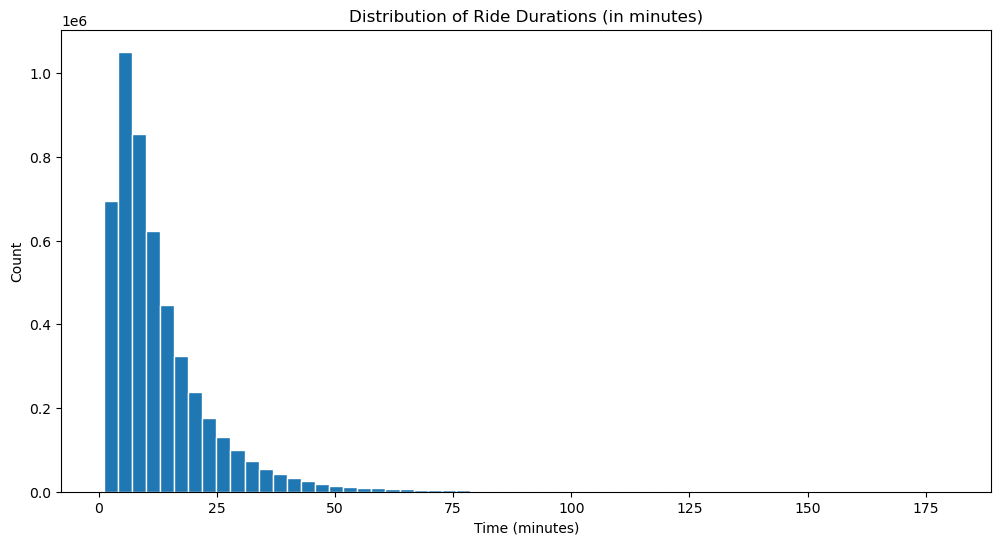

In [ ]:
plt.figure(figsize=(12,6))
plt.hist(df['ride_duration'], bins = 60, density = False, edgecolor='white')
plt.xlabel('Time (minutes)')
plt.ylabel('Count')
plt.title('Distribution of Ride Durations (in minutes)')
plt.show()

## Ride Duration Summary Statistics

What is the expected ride duration (i.e., the average ride duration)? What is the empirical variance of ride duration? What is the probability that a ride duration is greater than 20 min?

In [ ]:
avg_ride_duration = df['ride_duration'].mean()
var_ride_duration = df['ride_duration'].var()
prob_over_20 = len(df[df['ride_duration'] > 20])/len(df)
print("Average ride duration: " + str(round(avg_ride_duration, 2)) + ' minutes')
print("Variance of ride duration: " + str(round(var_ride_duration, 2)) + ' minutes')
print("Probability ride > 20 min:" , str(round(prob_over_20, 5)))

Average ride duration: 13.07 minutes
Variance of ride duration: 154.2 minutes
Probability ride > 20 min: 0.17785


## Conditional Probability of Long Rides Given Membership

What is the probability that a ride duration is greater than 20 min conditioning on the fact that the user is a CitiBike member? Note that the last
column gives whether the ride is for a casual
client or a CitiBike member.

In [ ]:
subset = df[(df['ride_duration'] > 20) & (df['member_casual'] == 'member')]
members = df[df['member_casual'] == 'member']
prob = len(subset)/len(members)
print('Probability ride > 20 min given member: ', str(round(prob, 5)))

Probability ride > 20 min given member:  0.14403


## Posterior Probability of Membership for Extended Rides

Suppose that the duration of some ride is more than 25 min. What is the probability that this ride
belongs to a CitiBike member?

In [ ]:
over_25 = df[df['ride_duration'] > 25]
prob = len(over_25[over_25['member_casual'] == 'member'])/len(over_25)
print('Probablity member given ride > 25 min: ', str(round(prob, 5)))

Probablity member given ride > 25 min:  0.59912


## Expected Ride Duration by Bike Type

What is the expected ride duration of an electric bike? What is the expected ride duration of a
classic bike?

In [ ]:
electric = df[df['rideable_type'] == 'electric_bike']
classic = df[df['rideable_type'] == 'classic_bike']
avg_electric = electric['ride_duration'].mean()
avg_classic = classic['ride_duration'].mean()
print('Average ride duration of an electric bike: ', str(round(avg_electric, 2)) + ' minutes')
print('Average ride duration of a classic bike: ', str(round(avg_classic, 2)) + ' minutes')

Average ride duration of an electric bike:  13.28 minutes
Average ride duration of a classic bike:  12.55 minutes


## Bike Type Likelihood for Short Rides

Suppose that the duration of some ride is less than 10min. What is the probability that this ride uses an electric bike? What is the probability that this ride uses a classic bike? Comment on the
results.



In [ ]:
less_10 = df[df['ride_duration'] < 10]
electric_less10 = less_10[less_10['rideable_type'] == 'electric_bike']
classic_less10 = less_10[less_10['rideable_type'] == 'classic_bike']
print('Probability that the bike is electric given that the ride is less than 10 min: ', str(round(len(electric_less10)/len(less_10), 5)))
print('Probability that the bike is classic given that the ride is less than 10 min: ', str(round(len(classic_less10)/len(less_10), 5)))

Probability that the bike is electric given that the ride is less than 10 min:  0.68702
Probability that the bike is classic given that the ride is less than 10 min:  0.31298


# Project

### Choose 3 High-Traffic Stations

In [ ]:
df['day_of_week'] = pd.to_datetime(df['started_at']).dt.dayofweek
df_weekday = df[df['day_of_week'] < 5].copy()
df_weekday.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration,day_of_week
0,BF31E940F7D80958,electric_bike,2025-07-11 18:42:36.430,2025-07-11 18:46:37.195,N 6 St & Bedford Ave,5379.10,Broadway & Berry St,5164.05,40.717452,-73.958509,40.710361,-73.965304,member,4.012750,4
2,9AFD3BA9E53733E7,electric_bike,2025-07-02 19:38:18.759,2025-07-02 20:10:05.899,Macon St & Howard Ave,4408.07,Stockholm St & Wilson Ave,4824.03,40.684520,-73.920110,40.699304,-73.923044,casual,31.785667,2
3,146A0E14AC873008,classic_bike,2025-07-04 22:03:19.382,2025-07-04 22:37:20.104,Clark St & Henry St,4789.03,Marcus Garvey Blvd & Macon St,4278.03,40.697601,-73.993446,40.682601,-73.938037,member,34.012033,4
4,54D1DCA4B21AC7C1,electric_bike,2025-07-07 18:20:14.380,2025-07-07 18:36:38.257,N 6 St & Bedford Ave,5379.10,Stockholm St & Wilson Ave,4824.03,40.717452,-73.958509,40.699304,-73.923044,member,16.397950,0
5,8AACA5F783C6A20A,electric_bike,2025-07-10 08:13:50.768,2025-07-10 08:22:47.372,Rivington St & Ridge St,5406.02,Broadway & Berry St,5164.05,40.718502,-73.983299,40.710361,-73.965304,member,8.943400,3


In [ ]:
print(f"Total rows (all days): {len(df)}")
print(f"Total rows (weekdays only): {len(df_weekday)}")

Total rows (all days): 4977775
Total rows (weekdays only): 3730281


In [ ]:
starts = df_weekday['start_station_name'].value_counts()
ends = df_weekday['end_station_name'].value_counts()
total_activity = starts.add(ends, fill_value=0)

In [ ]:
top_stations = total_activity.sort_values(ascending=False).head(10)
print(top_stations)

W 21 St & 6 Ave             26229.0
9 Ave & W 33 St             24599.0
Pier 61 at Chelsea Piers    24591.0
West St & Chambers St       24323.0
Lafayette St & E 8 St       23251.0
W 31 St & 7 Ave             22748.0
E 33 St & 1 Ave             21429.0
Broadway & E 14 St          21016.0
11 Ave & W 41 St            20968.0
W 30 St & 10 Ave            20735.0
Name: count, dtype: float64


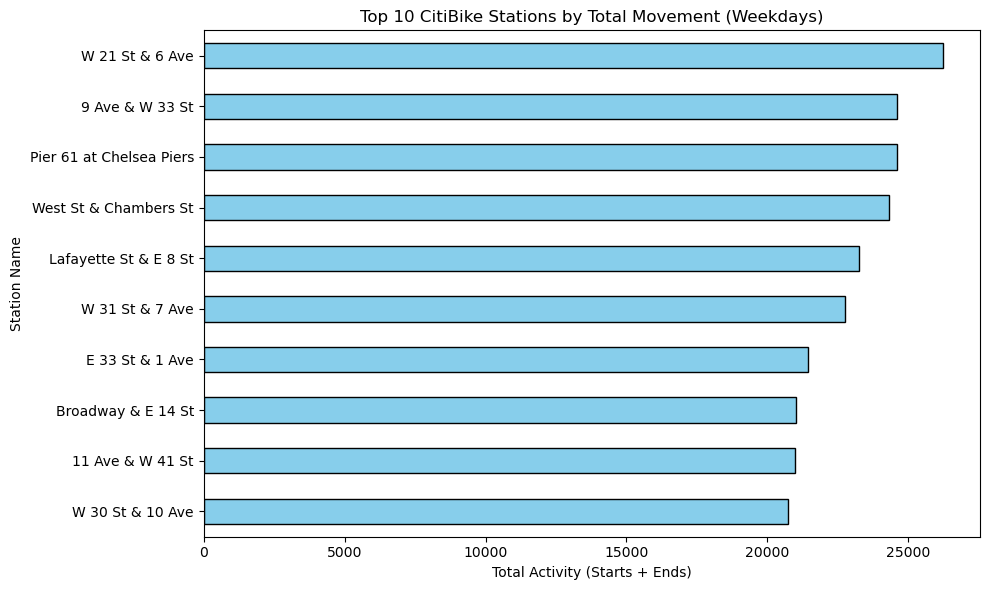

In [ ]:
plt.figure(figsize=(10, 6))
top_stations.sort_values().plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Top 10 CitiBike Stations by Total Movement (Weekdays)')
plt.xlabel('Total Activity (Starts + Ends)')
plt.ylabel('Station Name')
plt.tight_layout()
plt.show()

We will use the following three stations: 1. W 21 St & 6 Ave, 2. 9 Ave & W 33 St, 3. Pier 61 at Chelsea Piers

### Check Morning and Evening Time Intervals

In [ ]:
target_stations = [
    "W 21 St & 6 Ave",
    "E 33 St & 1 Ave",
    "West St & Chambers St"
]

In [ ]:
df_weekday['started_at'] = pd.to_datetime(df['started_at'])
df_weekday['ended_at'] = pd.to_datetime(df['ended_at'])
activity_times = []
am_start = [7, 6, 6]
am_end = [11, 10, 10]
pm_start = [16, 16, 17]
pm_end = [20, 20, 20]

### See Arrivals & Departures Split Up

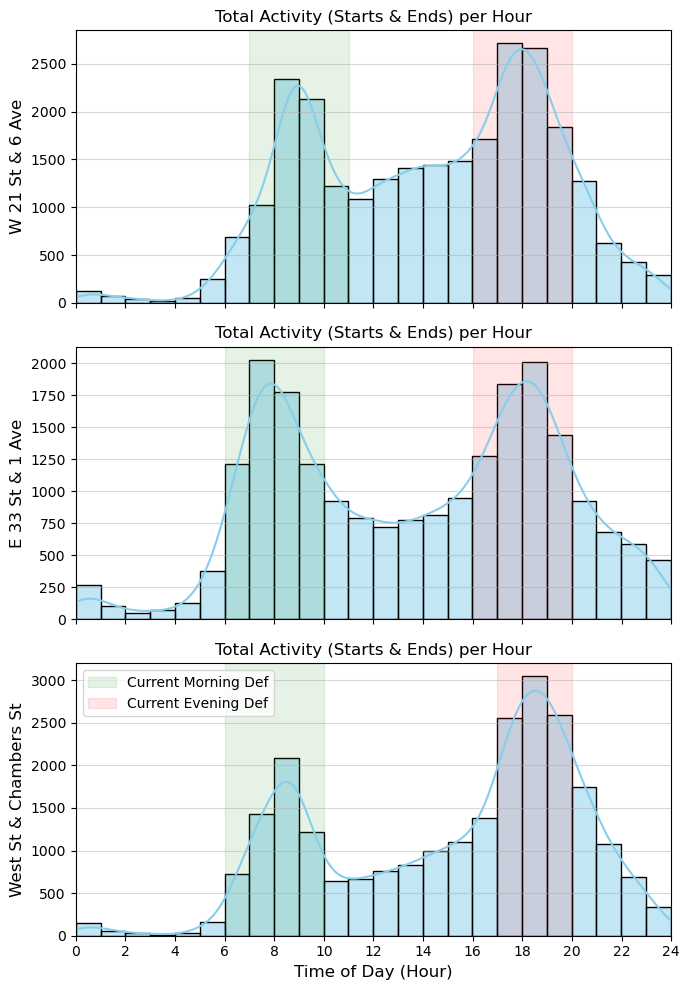

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(7, 10), sharex=True)

for i, station in enumerate(target_stations):
    ax = axes[i]

    starts = df_weekday[df_weekday['start_station_name'] == station]['started_at']
    ends = df_weekday[df_weekday['end_station_name'] == station]['ended_at']

    all_activity = pd.concat([starts, ends])
    hours = all_activity.dt.hour + all_activity.dt.minute / 60

    sns.histplot(hours, bins=24, kde=True, color='skyblue', edgecolor='black', ax=ax)

    ax.set_title('Total Activity (Starts & Ends) per Hour')
    ax.set_ylabel(f'{station}', fontsize=12)
    ax.grid(axis='y', alpha=0.5)
    ax.set_xlim(0, 24)

    ax.axvspan(am_start[i], am_end[i], color='green', alpha=0.1, label='Current Morning Def')

    ax.axvspan(pm_start[i], pm_end[i], color='red', alpha=0.1, label='Current Evening Def')

axes[2].legend(loc='upper left')
plt.xlabel('Time of Day (Hour)', fontsize=12)
plt.xticks(range(0, 25, 2))

plt.tight_layout()
plt.show()

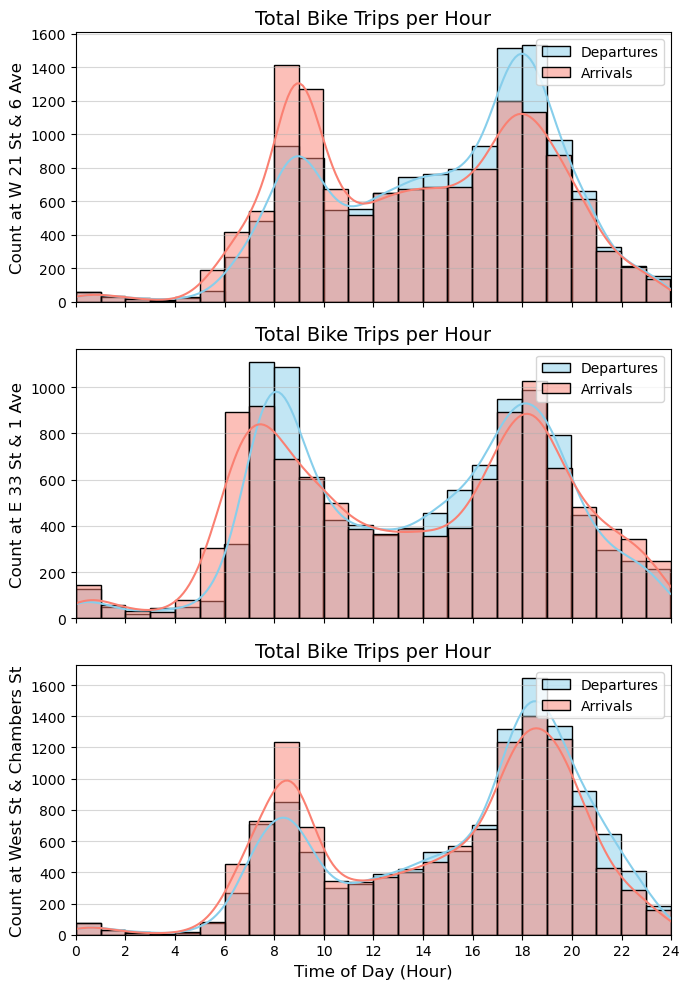

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(7, 10), sharex=True)

for i, station in enumerate(target_stations):
    ax = axes[i]

    starts = df_weekday[df_weekday['start_station_name'] == station]['started_at']
    departure_hours = starts.dt.hour + starts.dt.minute / 60

    sns.histplot(
        departure_hours,
        bins=24,
        kde=True,
        color='skyblue',
        edgecolor='black',
        label='Departures',
        ax=ax
    )

    ends = df_weekday[df_weekday['end_station_name'] == station]['ended_at']
    arrival_hours = ends.dt.hour + ends.dt.minute / 60

    sns.histplot(
        arrival_hours,
        bins=24,
        kde=True,
        color='salmon',
        edgecolor='black',
        label='Arrivals',
        ax=ax
    )

    ax.set_title('Total Bike Trips per Hour', fontsize=14)
    ax.set_ylabel(f'Count at {station}', fontsize=12)
    ax.grid(axis='y', alpha=0.5)
    ax.set_xlim(0, 24)

    ax.legend(loc='upper right', fontsize=10)

plt.xlabel('Time of Day (Hour)', fontsize=12)
plt.xticks(range(0, 25, 2))

plt.tight_layout()
plt.show()

## Decide on 5 or 10 minute intervals

In [ ]:
def interval_analysis(interval, df):
    print(f"For {interval} minute intervals: \n")

    for station in target_stations:
        starts = df[df['start_station_name'] == station][['started_at']].copy()
        ends = df[df['end_station_name'] == station][['ended_at']].copy()

        starts.columns = ['timestamp']
        ends.columns = ['timestamp']

        starts['activity'] = 1
        ends['activity'] = 1

        all_activity = pd.concat([starts, ends]).set_index('timestamp')

        bucketed = all_activity.resample(f"{interval}min").count()

        is_morning = (bucketed.index.hour >= am_start[i]) & (bucketed.index.hour < am_end[i])
        is_evening = (bucketed.index.hour >= pm_start[i]) & (bucketed.index.hour < pm_end[i])

        bucketed = bucketed[(is_morning) | (is_evening)]

        avg_activity = bucketed['activity'].mean()
        zero_activity_pct = (bucketed['activity'] == 0).mean() * 100
        max_activity = bucketed['activity'].max()

        print(f"Station: {station}")
        print(f"  Avg events per interval: {avg_activity:.2f}")
        print(f"  Max events in one interval: {max_activity}")
        print(f"  Intervals with ZERO activity: {zero_activity_pct:.1f}%")


In [ ]:
interval_analysis(5, df_weekday)

For 5 minute intervals: 

Station: W 21 St & 6 Ave
  Avg events per interval: 5.14
  Max events in one interval: 26
  Intervals with ZERO activity: 29.1%
Station: E 33 St & 1 Ave
  Avg events per interval: 4.42
  Max events in one interval: 23
  Intervals with ZERO activity: 27.9%
Station: West St & Chambers St
  Avg events per interval: 5.25
  Max events in one interval: 30
  Intervals with ZERO activity: 29.8%


In [ ]:
interval_analysis(10, df_weekday)

For 10 minute intervals: 

Station: W 21 St & 6 Ave
  Avg events per interval: 10.29
  Max events in one interval: 38
  Intervals with ZERO activity: 26.5%
Station: E 33 St & 1 Ave
  Avg events per interval: 8.85
  Max events in one interval: 35
  Intervals with ZERO activity: 26.1%
Station: West St & Chambers St
  Avg events per interval: 10.49
  Max events in one interval: 43
  Intervals with ZERO activity: 27.0%


We choose 5 minute time intervals because it has an average activity of about 5 bikes. This makes it manageable for a step-by-step transition model while still capturing the high-frequency nature of these busy stations. The "Zero Activity" percentage (intervals where nothing happens) is nearly identical (~27%) for both. We aren't gaining any "stability" by moving to 10 minutes. We're just losing detail.

## Get Capacity for Each Station

Used the following map to get capacity data: https://account.citibikenyc.com/map.

Max Capacity = Classic Bikes Available + Ebikes Available + Open Docks

In [ ]:
target_capacity = [64, 75, 82]

## Generate Stationary Distribution Matrix

am_start = [7, 6, 6]
am_end = [11, 10, 10]
pm_start = [16, 16, 17]
pm_end = [20, 20, 20]

In [ ]:
def get_station_dist(station_name, capacity, block_start, block_end, smooth):
    n = capacity+1
    freq_matrix = np.zeros((n, n), dtype=int)

    start_filter =  (df_weekday['start_station_name'] == station_name) & (df_weekday['started_at'].dt.hour >= block_start) & (df_weekday['started_at'].dt.hour < block_end)
    end_filter =  (df_weekday['end_station_name'] == station_name) & (df_weekday['ended_at'].dt.hour >= block_start) & (df_weekday['ended_at'].dt.hour < block_end)

    starts_df = pd.DataFrame({'timestamp': df_weekday.loc[start_filter, 'started_at'], 'change': -1})
    ends_df = pd.DataFrame({'timestamp': df_weekday.loc[end_filter, 'ended_at'], 'change': 1})

    events_df = pd.concat([starts_df, ends_df]).sort_values('timestamp').reset_index(drop=True)
    events_df = events_df.set_index('timestamp')

    bucketed_df = events_df['change'].resample("5min").sum().fillna(0)

    states_array = np.zeros(len(bucketed_df), dtype=int)
    current_inventory = capacity // 2

    for i, change in enumerate(bucketed_df.values):
        next_inventory = current_inventory + change
        clamped_inventory = np.clip(next_inventory, 0, capacity)
        states_array[i] = clamped_inventory
        current_inventory = clamped_inventory

    states = pd.Series(states_array, index=bucketed_df.index)

    for ind in range(len(states)-1):
        i = states.iloc[ind]
        j = states.iloc[ind+1]
        freq_matrix[i][j] += 1

    if smooth == False:
        row_sums = freq_matrix.sum(axis=1)
        p_matrix = np.divide(freq_matrix.astype(float), row_sums[:, np.newaxis], out=np.zeros_like(freq_matrix, dtype=float), where=row_sums[:, np.newaxis] != 0)

    if smooth == True:
        freq_matrix_smoothed = freq_matrix + 1
        row_sums_smoothed = freq_matrix_smoothed.sum(axis=1)
        p_matrix = np.divide(freq_matrix_smoothed.astype(float), row_sums_smoothed[:, np.newaxis], out=np.zeros_like(freq_matrix_smoothed, dtype=float), where=row_sums_smoothed[:, np.newaxis] != 0)

    vals, vecs = la.eig(p_matrix.T)
    pi = vecs[:, np.isclose(vals, 1)].flatten().real
    pi /= pi.sum()
    np.set_printoptions(suppress=True)

    print(f"Stationary Distribution (pi) of {station_name} from {block_start} - {block_end}:")
    print(pi)

## Generate Stationary Distributions for Each Station and Time Block

In [ ]:
get_station_dist(target_stations[0], 64, 7, 11, False)
print("\n")
get_station_dist(target_stations[0], 64, 16, 20, False)


Stationary Distribution (pi) of W 21 St & 6 Ave from 7 - 11:
[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.         -0.         -0.         -0.         -0.          0.
 -0.          0.         -0.          0.          0.          0.
  0.         -0.          0.          0.         -0.          0.000418
  0.00043199  0.0016413   0.00193879  0.05660302  0.00324498  0.05967096
  0.03358357  0.00965679  0.0393083   0.22377167  0.56973064]


Stationary Distribution (pi) of W 21 St & 6 Ave from 16 - 20:
[ 0.22833699  0.12693159  0.09365823  0.06660546  0.00856613  0.0606275
  0.18231656  0.12355368  0.09608699  0.00376734  0.00258029  0.00217984
  0.

In [ ]:
get_station_dist(target_stations[1], 75, 6, 10, False)
print("\n")
get_station_dist(target_stations[1], 75, 16, 20, False)

Stationary Distribution (pi) of E 33 St & 1 Ave from 6 - 10:
[0.00384529 0.00084116 0.00120165 0.00060083 0.0295606  0.00096132
 0.02980103 0.00096132 0.0298009  0.00108148 0.00048066 0.0016823
 0.03004081 0.00144197 0.02991978 0.03016151 0.03256384 0.10154403
 0.00300324 0.00348352 0.03036015 0.03098702 0.03122454 0.10053403
 0.00323509 0.00214594 0.00227679 0.0306265  0.00263107 0.00154655
 0.0024931  0.03034171 0.02959973 0.02957255 0.00343393 0.00279838
 0.00241552 0.00225778 0.00225284 0.02856199 0.02853053 0.00214842
 0.11639277 0.00151121 0.00107768 0.00140038 0.00172301 0.00140024
 0.00096936 0.00075351 0.00075395 0.00150772 0.00183072 0.00086149
 0.         0.00096919 0.00053842 0.00086148 0.00021533 0.0007538
 0.00118451 0.00053842 0.00064611 0.00096915 0.00086148 0.00021537
 0.00075379 0.00118453 0.00096916 0.00172295 0.02735178 0.00258442
 0.0897009  0.00086147 0.0006461  0.00333821]


Stationary Distribution (pi) of E 33 St & 1 Ave from 16 - 20:
[ 0.14710083  0.03675118  0

In [ ]:
get_station_dist(target_stations[2], 82, 6, 10, False)
print("\n")
get_station_dist(target_stations[2], 82, 17, 20, False)

Stationary Distribution (pi) of West St & Chambers St from 6 - 10:
[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.         -0.         -0.
 -0.         -0.         -0.         -0.         -0.         -0.
  0.         -0.         -0.         -0.         -0.          0.
  0.          0.         -0.          0.          0.         -0.
  0.          0.00004836  0.          0.00009671  0.00012895  0.00012578
  0.00003224  0.00019817  0.00046772  0.00060876  0.00082915  0.00090239
  0.0008323   0.05457677  0.00178006  0.00256834  0.00349416  0.03229819
  0.15525367  0.0641785   0.09604758  0.34881036  0.23672185]




# Run Simulation

In [ ]:
# Assuming your capacity is 42 (N=43 states)
N = p_matrix.shape[0]

# --- Define initial distribution (e.g., guaranteed half-full) ---
x0 = np.zeros(N)
initial_state_index = N // 2  # State 21 for capacity=42
x0[initial_state_index] = 1.0